# 1. Environment Setup

In [61]:
import sys
import subprocess
import pkgutil


# Required packages
required_packages = {
    'pandas': 'pandas',
    'numpy': 'numpy',
    'pyarrow': 'pyarrow',
    'pillow': 'pillow',
    'matplotlib': 'matplotlib',
    'requests': 'requests',
}


print("Checking and installing missing dependencies... \n")
missing = []
for module_name, package_name in required_packages.items():
    if pkgutil.find_loader(module_name) is None:
        missing.append(package_name)

if missing:
    print(f"Installing missing packages: {','.join(missing)}. \n")
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q'] + missing)
    print("Installation complete. \n")
else:
    print("All dependencies already installed.\n")

Checking and installing missing dependencies... 

Installing missing packages: pillow. 

Installation complete. 



In [62]:
import os
import pandas as pd
import numpy as np
import requests
from tqdm import tqdm
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt

print("All required libraries imported successfully.")

All required libraries imported successfully.


# 2. Configuration

In [63]:
DATA_PATH = "../data/processed/amazon_reviews_s30.parquet"
MULTIMODAL_DATA = "../data/multimodel/dataset_50k.parquet"
IMAGE_DIR = "../data/multimodel/images"

os.makedirs(IMAGE_DIR, exist_ok=True)

# 3. Load the dataset

In [64]:
df = pd.read_parquet(MULTIMODAL_DATA)

print("Dataset size:", len(df))

Dataset size: 50000


## 3.1. Dataset Preview

In [65]:
df.head()

,rating,images,parent_asin,timestamp,helpful_vote,review_text,review_length,is_verified,image_count,has_image,days_since_first_review,product_popularity,label,image_url,image_path
448388,5,[],B01GH3ZALM,2016-08-05 11:29:47.000,2,Best case ever This case is so cute and I cons...,66,1,0,False,7199,6,0,NaN,NaN
289218,5,[],B0087NZ31S,2013-03-15 13:28:16.000,1,It does what it says Installation was amazingl...,337,1,0,False,5960,4358,0,NaN,NaN
961876,4,[],B09K7VVR63,2023-04-13 01:44:19.271,1,Ok product with one problem Mostly good with e...,208,1,0,False,9641,61,0,NaN,NaN
2548084,4,[],B0BFM2GP2B,2016-02-25 06:15:57.000,1,you're just dumb. Mainly writing this review t...,259,0,0,False,7037,557,0,NaN,NaN
20266,5,[],B0051VVOB2,2012-02-16 07:40:56.000,1,"Wonderful device, well worth it for the price ...",361,1,0,False,5567,13072,0,NaN,NaN


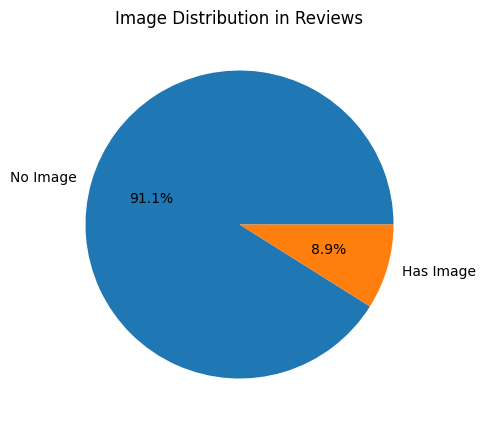


📸 Image Distribution:
  Has Image: 4,466 reviews (8.9%)
  No Image: 45,534 reviews (91.1%)


In [66]:
# Image Distribution
plt.figure(figsize=(8,5))
has_image = df['images'].map(len).gt(0).value_counts()

plt.pie(
    has_image.values,
    labels=['Has Image' if i else 'No Image' for i in has_image.index],
    autopct='%1.1f%%'
)
plt.title('Image Distribution in Reviews')
plt.show()

image_counts = (
    df["images"]
    .astype(str)
    .apply(lambda x: x != "[]" and x != "nan")
    .value_counts()
)
print(f"\n📸 Image Distribution:")
print(f"  Has Image: {image_counts.get(True, 0):,} reviews ({image_counts.get(True, 0)/len(df)*100:.1f}%)")
print(f"  No Image: {image_counts.get(False, 0):,} reviews ({image_counts.get(False, 0)/len(df)*100:.1f}%)")

In [67]:
# Debug: Check the structure of images data
print("Sample image data:")
for i in range(25, 28):
    print(f"\nRow {i}:")
    print(f"  Type: {type(df['images'].iloc[i])}")
    print(f"  Value: {df['images'].iloc[i]}")
    if isinstance(df['images'].iloc[i], list) and len(df['images'].iloc[i]) > 0:
        print(f"  First item type: {type(df['images'].iloc[i][0])}")
        print(f"  First item: {df['images'].iloc[i][0]}")

Sample image data:

Row 25:
  Type: <class 'numpy.ndarray'>
  Value: [{'attachment_type': 'IMAGE', 'large_image_url': 'https://images-na.ssl-images-amazon.com/images/I/91PJVt+OY-L._SL1600_.jpg', 'medium_image_url': 'https://images-na.ssl-images-amazon.com/images/I/91PJVt+OY-L._SL800_.jpg', 'small_image_url': 'https://images-na.ssl-images-amazon.com/images/I/91PJVt+OY-L._SL256_.jpg'}]

Row 26:
  Type: <class 'numpy.ndarray'>
  Value: []

Row 27:
  Type: <class 'numpy.ndarray'>
  Value: []


# 4. Extract Image Outline

In [68]:
def extract_first_image_url(images_column):

    if isinstance(images_column, np.ndarray):
        images_column = images_column.tolist()

    # Empty list
    if len(images_column) == 0:
        return None

    first = images_column[0]

    # Priority selection
    return (
        first.get("large_image_url")
        or first.get("medium_image_url")
        or first.get("small_image_url")
    )

## 4.1. Create URL column

In [69]:
df["image_url"] = df["images"].apply(extract_first_image_url)

print("Images available:", df["image_url"].notna().sum())

Images available: 4466


In [70]:
df.iloc[20:30][["images", "image_url"]]

,images,image_url
1394083,[],NaN
767060,[],NaN
1613606,[],NaN
1294878,[],NaN
2417392,"[{'attachment_type': 'IMAGE', 'large_image_url...",https://images-na.ssl-images-amazon.com/images...
2309935,"[{'attachment_type': 'IMAGE', 'large_image_url...",https://images-na.ssl-images-amazon.com/images...
838367,[],NaN
467409,[],NaN
356196,[],NaN
2548792,[],NaN


# 5. Download Image

In [71]:
def download_image(url, save_path):
    try:
        response = requests.get(url, timeout=10)

        if response.status_code != 200:
            print(f"HTTP Error {response.status_code}: {url}")
            return False

        image = Image.open(BytesIO(response.content))
        image.verify()  # validate image

        with open(save_path, "wb") as f:
            f.write(response.content)

        return True

    except requests.exceptions.Timeout:
        print(f"Timeout: {url}")
        return False
    except requests.exceptions.ConnectionError:
        print(f"Connection Error: {url}")
        return False
    except Exception as e:
        print(f"Error: {type(e).__name__} - {url}")
        return False

## 5.1. Download Loop

In [75]:
success = 0
failed = 0

for idx, row in tqdm(df.iterrows(), total=len(df)):

    url = row["image_url"]

    if pd.isna(url):
        continue

    filename = f"{idx}.jpg"
    save_path = os.path.join(IMAGE_DIR, filename)

    # Skip already downloaded images
    if os.path.exists(save_path):
        success += 1
        continue

    ok = download_image(url, save_path)

    if ok:
        success += 1
    else:
        failed += 1

print(f"\n\nDownloaded: {success}")
print(f"Failed: {failed}")

  5%|▍         | 2451/50000 [00:00<00:05, 8479.41it/s]

HTTP Error 404: https://images-na.ssl-images-amazon.com/images/I/71XHeHQweoL.jpg
HTTP Error 404: https://images-na.ssl-images-amazon.com/images/I/71daDyg6HWL.jpg


 12%|█▏        | 5830/50000 [00:00<00:03, 11662.97it/s]

HTTP Error 404: https://images-na.ssl-images-amazon.com/images/I/61WlEzT7GnL.jpg
HTTP Error 404: https://m.media-amazon.com/images/I/71Y83a5zyAL._SL1600_.jpg


 22%|██▏       | 10755/50000 [00:00<00:02, 16974.61it/s]

...

HTTP Error 404: https://m.media-amazon.com/images/I/71L731UPr2L._SL1600_.jpg


 94%|█████████▍| 47085/50000 [00:03<00:00, 15979.33it/s]

HTTP Error 404: https://images-na.ssl-images-amazon.com/images/I/61EvCM4-CXL._SL1600_.jpg
HTTP Error 404: https://images-na.ssl-images-amazon.com/images/I/61OEQcKyaCL.jpg


100%|██████████| 50000/50000 [00:03<00:00, 15586.12it/s]



Downloaded: 4445
Failed: 21


# 6. Save Image Mapping

In [76]:
def get_path(i):
    p = os.path.join(IMAGE_DIR, f"{i}.jpg")
    return p if os.path.exists(p) else None

df["image_path"] = df.index.map(get_path)
df["has_image"] = df["image_path"].notna()

df.iloc[20:30][["image_url", "image_path", "has_image"]]

,image_url,image_path,has_image
1394083,NaN,NaN,False
767060,NaN,NaN,False
1613606,NaN,NaN,False
1294878,NaN,NaN,False
2417392,https://images-na.ssl-images-amazon.com/images...,../data/multimodel/images\2417392.jpg,True
2309935,https://images-na.ssl-images-amazon.com/images...,../data/multimodel/images\2309935.jpg,True
838367,NaN,NaN,False
467409,NaN,NaN,False
356196,NaN,NaN,False
2548792,NaN,NaN,False


In [80]:
print(f"Dataset shape: {df.shape[0]:2,} rows x {df.shape[1]} columns")

print(f"\nDataset Columns with dtypes: \n{df.dtypes}")

Dataset shape: 50,000 rows x 15 columns

Dataset Columns with dtypes: 
rating                               int8
images                             object
parent_asin                      category
timestamp                  datetime64[ms]
helpful_vote                        int32
review_text                           str
review_length                       int32
is_verified                          int8
image_count                         int16
has_image                            bool
days_since_first_review             int32
product_popularity                  int32
label                               int64
image_url                             str
image_path                            str
dtype: object


In [ ]:
df.to_parquet(DATA_PATH)

print("Dataset updated with image paths.")